# Frequency of Tweets Containing #OscarsSoWhite
- This notebook contains an analysis of the frequency of Tweets containing #OscarsSoWhite, includding timelines of when these tweets were made

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [3]:
oscarssowhite = pd.read_csv('../data/oscarssowhite_timeline_2015-2022.csv')

In [4]:
oscarssowhite['date_dt']=pd.to_datetime(oscarssowhite['date'], format='%m/%d/%Y')

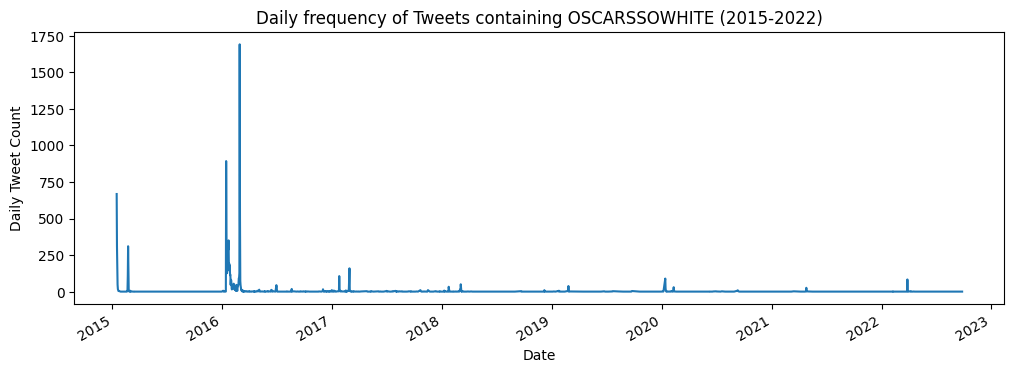

In [5]:
oscarssowhite.set_index('date_dt')['count'].plot(figsize=(12,4))
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.title('Daily frequency of Tweets containing OSCARSSOWHITE (2015-2022)')
plt.show()

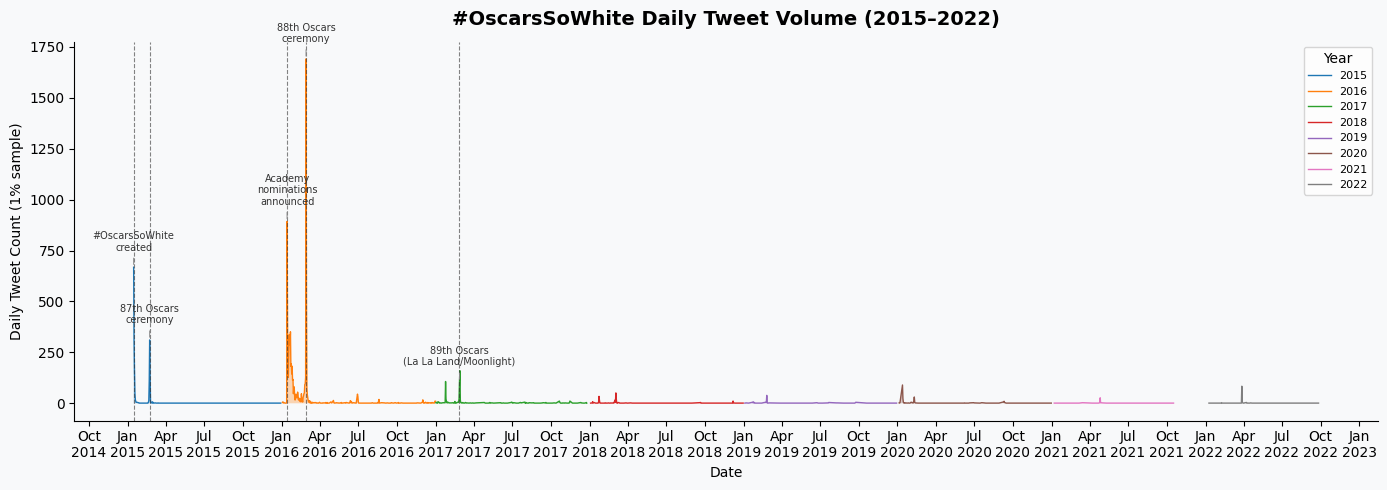

In [9]:
events = [
    ('2015-01-15', '#OscarsSoWhite\ncreated'),
    ('2015-02-22', '87th Oscars\nceremony'),
    ('2016-01-14', 'Academy\nnominations\nannounced'),
    ('2016-02-28', '88th Oscars\nceremony'),
    ('2017-02-26', '89th Oscars\n(La La Land/Moonlight)'),
]

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

for yr in sorted(oscarssowhite['year'].unique()):
    mask = oscarssowhite['year'] == yr
    ax.fill_between(oscarssowhite[mask]['date_dt'], oscarssowhite[mask]['count'], alpha=0.3)
    ax.plot(oscarssowhite[mask]['date_dt'], oscarssowhite[mask]['count'], linewidth=1, label=str(yr))

for date_str, label in events:
    dt = pd.to_datetime(date_str)
    val = oscarssowhite.set_index('date_dt')['count'].reindex([dt], method='nearest').iloc[0]
    ax.axvline(dt, color='#333', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.annotate(label, xy=(dt, val), xytext=(0, 12), textcoords='offset points',
                fontsize=7, ha='center', color='#333',
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.7))

ax.set_title('#OscarsSoWhite Daily Tweet Volume (2015–2022)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Tweet Count (1% sample)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.legend(title='Year', fontsize=8, loc='upper right', framealpha=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# In-depth look of these specific years

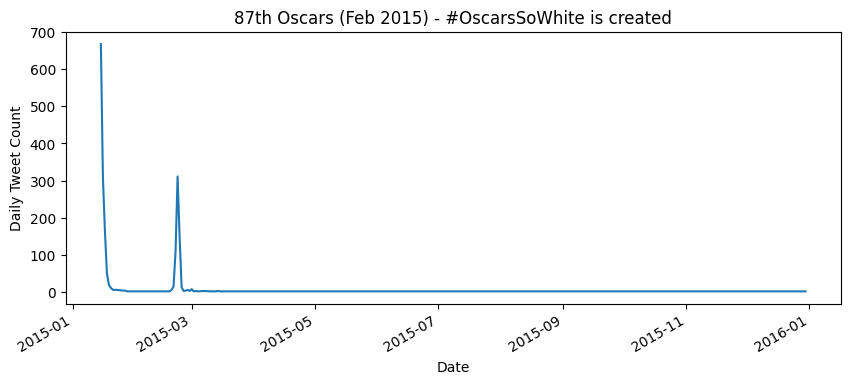

In [18]:
oscarssowhite.set_index('date_dt').loc['2015-01-01':'2015-12-31', 'count'].plot(figsize=(10, 4))
plt.title('87th Oscars (Feb 2015) - #OscarsSoWhite is created')
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.show()

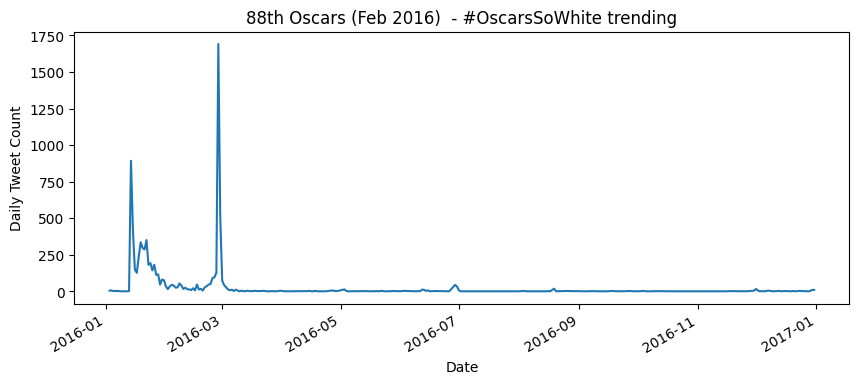

In [19]:
oscarssowhite.set_index('date_dt').loc['2016-01-01':'2016-12-31', 'count'].plot(figsize=(10, 4))
plt.title('88th Oscars (Feb 2016)  - #OscarsSoWhite trending')
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.show()

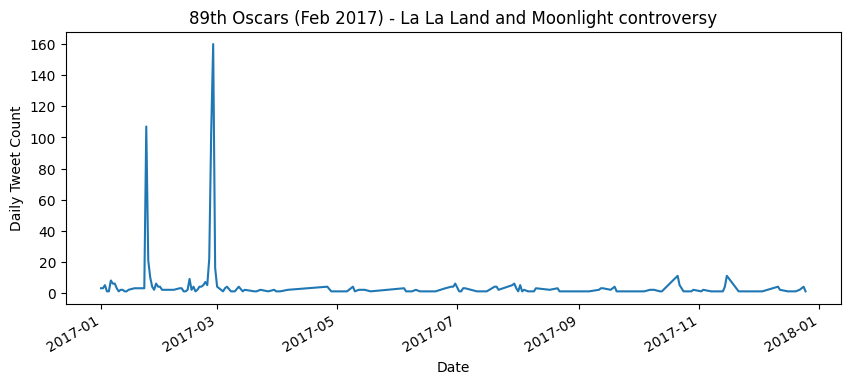

In [20]:
oscarssowhite.set_index('date_dt').loc['2017-01-01':'2017-12-31', 'count'].plot(figsize=(10, 4))
plt.title('89th Oscars (Feb 2017) - La La Land and Moonlight controversy')
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.show()

# Overview by year

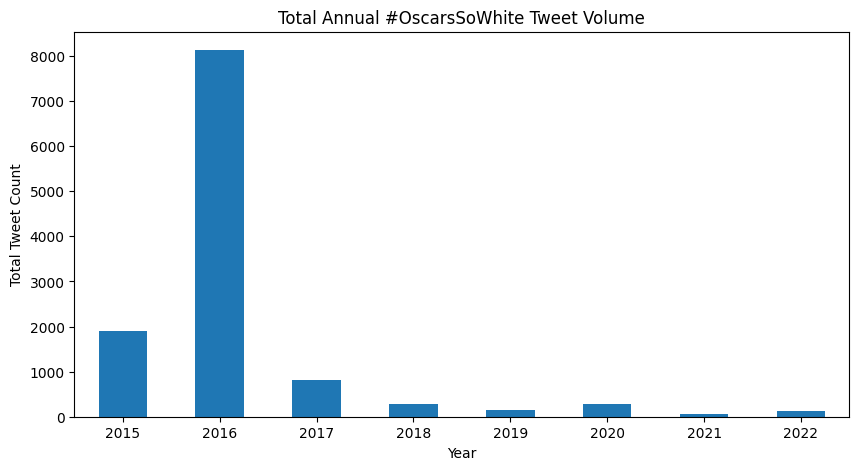

In [11]:
oscarssowhite.groupby('year')['count'].sum().plot(kind='bar', figsize=(10, 5))
plt.xlabel('Year')
plt.ylabel('Total Tweet Count')
plt.title('Total Annual #OscarsSoWhite Tweet Volume')
plt.xticks(rotation=0)
plt.show()